# Softmax Regression with TensorFlow

- 입력 변수: Iris 데이터의 4개 특성
- 출력 변수: 3개 품종 클래스 (`0`, `1`, `2`)
- 모델: Softmax Regression (`Dense` 1개 층, `softmax` 활성화 함수)
- 손실 함수: `sparse_categorical_crossentropy`

In [1]:
# TensorFlow 버전 확인
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow version:", tf.__version__)

# 재현 가능한 결과를 위한 시드 설정
tf.keras.utils.set_random_seed(0)

TensorFlow version: 2.20.0


In [2]:
# Iris 데이터셋 불러오기
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("특성 이름:", iris.feature_names)
print("클래스 이름:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스 이름: ['setosa' 'versicolor' 'virginica']


In [3]:
# 데이터 일부 확인
print("X[0:2] =\n", X[0:2])
print("y[0:2] =", y[0:2])

X[0:2] =
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
y[0:2] = [0 0]


## Softmax Regression 모델 구성

`Dense(3, activation='softmax')`는 4개의 입력 특성을 받아 3개 클래스에 대한 확률을 출력합니다.

각 입력 샘플 $x$에 대해 모델은 다음과 같은 확률 벡터를 출력합니다.

$$
P(y=k|x) = \frac{e^{z_k}}{\sum_{j=1}^{3}e^{z_j}}
$$

여기서 $z = Wx+b$이며, 세 확률의 합은 1입니다.

In [4]:
# Softmax Regression 모델 생성
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 모델 컴파일
# y가 정수형 클래스 레이블이므로 sparse_categorical_crossentropy를 사용합니다.
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# 모델 학습
history = model.fit(
    X,
    y,
    epochs=500,
    batch_size=16,
    shuffle=True,
    verbose=0
)

print("최종 loss:", history.history['loss'][-1])
print("최종 accuracy:", history.history['accuracy'][-1])

최종 loss: 0.17691676318645477
최종 accuracy: 0.9733333587646484


In [7]:
# 학습된 가중치와 편향 확인
weights, bias = model.layers[0].get_weights()
print("가중치 W의 shape:", weights.shape)
print(weights)
print("편향 b의 shape:", bias.shape)
print(bias)

가중치 W의 shape: (4, 3)
[[ 0.87458885  0.45871463 -1.0302821 ]
 [ 0.9521262  -0.5476277  -1.907575  ]
 [-1.8827487   0.42151934  2.4612286 ]
 [-0.993137   -0.6116714   2.154313  ]]
편향 b의 shape: (3,)
[ 0.3367936   0.43808416 -0.7748776 ]


## 예측

`model.predict()`의 결과는 각 클래스에 대한 확률입니다. sklearn의 `predict_proba()`와 대응합니다.

확률이 가장 큰 클래스는 `argmax`로 선택합니다. sklearn의 `predict()`와 대응하는 부분입니다.

In [8]:
# 클래스별 예측 확률: sklearn의 predict_proba()에 해당
y_prob = model.predict(X, verbose=0)
print("예측 확률 일부:\n", y_prob[:2])
print("각 행의 확률 합:", y_prob[:2].sum(axis=1))

# 클래스 예측: sklearn의 predict()에 해당
y_hat = np.argmax(y_prob, axis=1)
print("예측 클래스:\n", y_hat)

예측 확률 일부:
 [[9.8141247e-01 1.8586855e-02 7.2060760e-07]
 [9.5824891e-01 4.1746736e-02 4.3028499e-06]]
각 행의 확률 합: [1.0000001  0.99999994]
예측 클래스:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [9]:
# 학습 데이터에 대한 평가
loss, accuracy = model.evaluate(X, y, verbose=0)
print("loss:", loss)
print("accuracy:", accuracy)

loss: 0.17539146542549133
accuracy: 0.9800000190734863


In [10]:
# 혼동 행렬과 클래스별 예측 결과 확인
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion matrix:")
print(confusion_matrix(y, y_hat))

print("\nClassification report:")
print(classification_report(y, y_hat, target_names=iris.target_names))

Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  0 50]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      0.94      0.97        50
   virginica       0.94      1.00      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



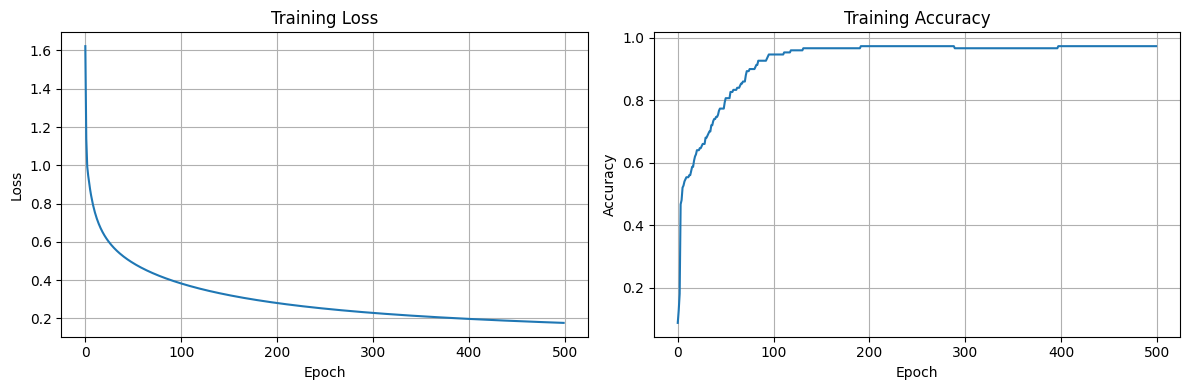

In [11]:
# 학습 과정 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history.history['accuracy'])
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 특정 데이터에 대한 예측

새로운 Iris 측정값을 입력하면 세 품종에 대한 확률과 최종 예측 클래스를 얻을 수 있습니다.

In [12]:
# 예시 입력: sepal length, sepal width, petal length, petal width
new_data = np.array([[5.1, 3.5, 1.4, 0.2]], dtype=np.float32)
new_prob = model.predict(new_data, verbose=0)
new_class = np.argmax(new_prob, axis=1)[0]

print("클래스별 확률:", new_prob[0])
print("예측 클래스 번호:", new_class)
print("예측 품종:", iris.target_names[new_class])

클래스별 확률: [9.814124e-01 1.858686e-02 7.206061e-07]
예측 클래스 번호: 0
예측 품종: setosa
